## **KNN - K Nearest Neighbors**

`Goal: - keywords`

- Definition
- Strengths & Weakness
- How it works
- Coding:
    - EuclideanDistance
    - NearestNeighbors
    
---

### K-Nearest Neighbors (KNN) — Key Points

**Core idea**

- Non-parametric, instance-based ("lazy") learning algorithm. No training phase beyond storing the data; all computation happens at prediction time.
- Predicts based on the *k* closest training examples in feature space.
- Classification → majority vote of neighbors. Regression → mean (or weighted mean) of neighbors' values.

**The key hyperparameter: k**

- Small *k* (e.g., 1–3): low bias, high variance → sensitive to noise, can overfit.
- Large *k*: high bias, low variance → smoother decision boundary, can underfit.
- Odd *k* for binary classification to avoid ties. Tune via cross-validation.

**Distance metrics**

- Euclidean (default, L2), Manhattan (L1), Minkowski (general), Cosine (for high-dim / text), Hamming (categorical).
- Choice matters — feature geometry should match the metric.

**Feature scaling is critical**

- Distance-based, so features on larger scales dominate. Always standardize or normalize (e.g., StandardScaler, MinMaxScaler) before fitting.

**Weighting**

- Uniform: all *k* neighbors vote equally.
- Distance-weighted: closer neighbors get more influence (1/d or kernel weights) — usually better when *k* is larger.

**Strengths**

- Simple, intuitive, no training cost.
- Naturally handles multi-class problems.
- Decision boundary can be arbitrarily complex (non-linear) with enough data.
- Strong baseline, especially for low-dimensional problems.

**Weaknesses**

- Prediction is O(n·d) per query — slow on large datasets. Mitigate with KD-trees, Ball trees, or approximate methods (FAISS, Annoy, HNSW).
- Curse of dimensionality: distances become less meaningful in high dimensions; consider PCA or feature selection first.
- Sensitive to irrelevant/redundant features and to class imbalance.
- Memory-heavy (stores all training data).

**How it works:**

1.	Store all training data (no real training step).
2.	For a new point, compute distance to all training points (usually 
Euclidean).
3.	Find the K closest neighbors.
4.	Classification: majority vote among neighbors. Regression: average their values.**


**Key choices:**

- K: small K = low bias, high variance (noisy); large K = smoother, higher bias.
- Often pick odd K to avoid ties; tune via cross-validation.
- Distance metric: **Euclidean**, **Manhattan**, Minkowski, **cosine**.
- Feature scaling: **essential—features must be normalized/standardized** or large-scale features dominate the distance.
- Weighting: **can weight neighbors by inverse distance so closer points count more**.


    - **Euclidean**: is the straight line between two points.

    - **Manhattan**: is the distance between two points measured along axes at right angles. d = |x1- x2| + |y1 - y2|

**Tradeoffs:**

- Pros: simple, no training**, naturally handles multi-class, makes no distributional assumptions.
- Cons: slow at inference (computes all distances), memory-heavy (stores all data),** **suffers from the curse of dimensionality, sensitive to irrelevant features and scaling.**

**Some Q&A:**

How to decide the number of neighbors?

- There’s no closed-form answer. we tune it.

How to choose the center?

- there is no center, but just the k-means

How to calculate the loss?

- In KNN there’s no training loss to minimize - the ‘model’ is just the stored dataset. So evaluating loss means running predictions on held-out data and scoring them.

#### Euclidean Distance

In [100]:
def EuclideanDistance(v1, v2):
    sum = 0.0
    for index in range(len(v1)):
        sum += (v1[index] - v2[index]) ** 2
    return sum ** 0.5

#### Build Nearest Neighbor Class with neighbor as 1 (use iris data to test)

`Import packages`

In [128]:
import numpy as np
from sklearn import datasets
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

`Create the K Nearest Neighbor Classification`

In [102]:
class NearestNeighbors:
    def __init__(self, k=1): # initialize variables
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        # just store the training data
        self.X_train = X
        self.y_train = y
    
    def predict(self, X_test): # loop over all samples
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)
    
    def _predict_single(self, x):
        # calculate the Euclidean distance between single test value and all training value
        distance = np.sqrt(np.sum((self.X_train - x)**2, axis=1)) # return a list of Euclidean distance

        # find the index of the smallest distances
        k_indices = np.argsort(distance)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # return the label of the nearest neighbor
        most_common = Counter(k_nearest_labels).most_common(1)

        return most_common[0][0]

`Train and test on Iris Dataset`

In [103]:
# load data
iris = datasets.load_iris()
X = iris.data[:, [0,2]] # only use two features, because the plot_decision_regions only accept two dimensions
y = iris.target
features = iris.feature_names


# split to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# initialize the classifier
clf = NearestNeighbors(k=10)

# train the model
clf.fit(X_train, y_train)

# make prediciton
train_predictions = clf.predict(X_train)
test_predictions = clf.predict(X_test)

# evaludate accuracy
train_ccuracy = accuracy_score(y_train, train_predictions)
test_ccuracy = accuracy_score(y_test, test_predictions)

print(f'Train Accuracy: {train_ccuracy:.4f}')
print(f'Test Accuracy: {test_ccuracy:.4f}')

Train Accuracy: 0.9750
Test Accuracy: 1.0000


`Plot the decision boundary`

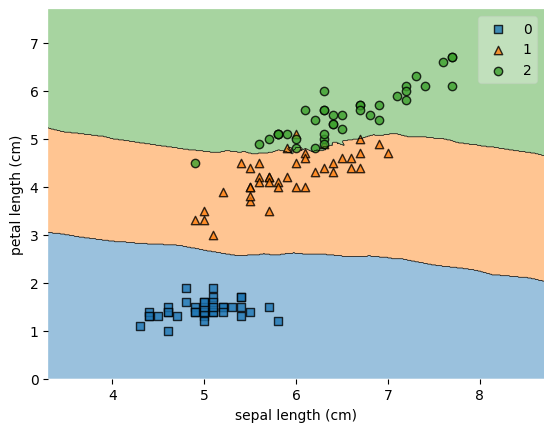

In [104]:
plot_decision_regions(X_train, y_train, clf=clf)
plt.xlabel(features[0])
plt.ylabel(features[2])
plt.show()

`Evaludation`
- `Confusion Matrix`

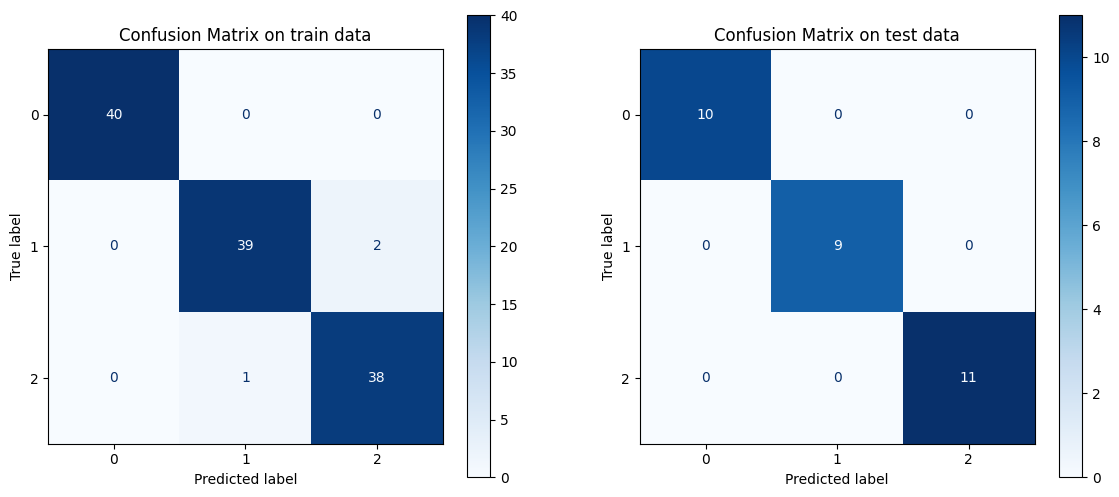

In [ ]:
test_matrix = confusion_matrix(y_test, test_predictions)
train_matrix = confusion_matrix(y_train, train_predictions)

fig, axes = plt.subplots(1,2, figsize=(14,6))

train_display = ConfusionMatrixDisplay(train_matrix)
train_display.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix on train data')

test_display = ConfusionMatrixDisplay(test_matrix)
test_display.plot(cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix on test data')

plt.show()

- `Classification Report`

In [124]:
# classification report on train
print('Classification report on training data:')
print(classification_report(y_train, train_predictions))

print('\nClassification report on test data:')
# classification report on test
print(classification_report(y_test, test_predictions))

Classification report on training data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.97      0.95      0.96        41
           2       0.95      0.97      0.96        39

    accuracy                           0.97       120
   macro avg       0.97      0.98      0.97       120
weighted avg       0.98      0.97      0.98       120


Classification report on test data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

